In [113]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator

from sklearn.cluster import KMeans
from sklearn import metrics
from kneed import KneeLocator
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

In [114]:
df = pd.read_csv("SUPERSTORE_DATASET.csv", sep=',')

In [115]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2019-103800,2019-01-03,2019-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
3,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
4,CA-2019-141817,2019-01-05,2019-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   str    
 1   Order Date     9994 non-null   str    
 2   Ship Date      9994 non-null   str    
 3   Ship Mode      9994 non-null   str    
 4   Customer ID    9994 non-null   str    
 5   Customer Name  9994 non-null   str    
 6   Segment        9994 non-null   str    
 7   Country        9994 non-null   str    
 8   City           9994 non-null   str    
 9   State          9994 non-null   str    
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   str    
 12  Product ID     9994 non-null   str    
 13  Category       9994 non-null   str    
 14  Sub-Category   9994 non-null   str    
 15  Product Name   9994 non-null   str    
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount       9994

In [117]:
# PADRONIZAÇÃO DE CONTEÚDO STRING

df.columns = df.columns.str.upper()
df.columns = df.columns.str.replace(" ", "_")
string_cols = df.select_dtypes(include=['string']).columns
df[string_cols] = df[string_cols].apply(lambda x: x.str.upper())

In [118]:
df.head()

,ORDER_ID,ORDER_DATE,SHIP_DATE,SHIP_MODE,CUSTOMER_ID,CUSTOMER_NAME,SEGMENT,COUNTRY,CITY,STATE,POSTAL_CODE,REGION,PRODUCT_ID,CATEGORY,SUB-CATEGORY,PRODUCT_NAME,SALES,QUANTITY,DISCOUNT,PROFIT
0,CA-2019-103800,2019-01-03,2019-01-07,STANDARD CLASS,DP-13000,DARREN POWERS,CONSUMER,UNITED STATES,HOUSTON,TEXAS,77095,CENTRAL,OFF-PA-10000174,OFFICE SUPPLIES,PAPER,"MESSAGE BOOK, WIREBOUND, FOUR 5 1/2"" X 4"" FORM...",16.448,2,0.2,5.5512
1,CA-2019-112326,2019-01-04,2019-01-08,STANDARD CLASS,PO-19195,PHILLINA OBER,HOME OFFICE,UNITED STATES,NAPERVILLE,ILLINOIS,60540,CENTRAL,OFF-LA-10003223,OFFICE SUPPLIES,LABELS,AVERY 508,11.784,3,0.2,4.2717
2,CA-2019-112326,2019-01-04,2019-01-08,STANDARD CLASS,PO-19195,PHILLINA OBER,HOME OFFICE,UNITED STATES,NAPERVILLE,ILLINOIS,60540,CENTRAL,OFF-ST-10002743,OFFICE SUPPLIES,STORAGE,SAFCO BOLTLESS STEEL SHELVING,272.736,3,0.2,-64.7748
3,CA-2019-112326,2019-01-04,2019-01-08,STANDARD CLASS,PO-19195,PHILLINA OBER,HOME OFFICE,UNITED STATES,NAPERVILLE,ILLINOIS,60540,CENTRAL,OFF-BI-10004094,OFFICE SUPPLIES,BINDERS,GBC STANDARD PLASTIC BINDING SYSTEMS COMBS,3.540,2,0.8,-5.4870
4,CA-2019-141817,2019-01-05,2019-01-12,STANDARD CLASS,MB-18085,MICK BROWN,CONSUMER,UNITED STATES,PHILADELPHIA,PENNSYLVANIA,19143,EAST,OFF-AR-10003478,OFFICE SUPPLIES,ART,AVERY HI-LITER EVERBOLD PEN STYLE FLUORESCENT ...,19.536,3,0.2,4.8840


In [119]:
df.isnull().sum()

ORDER_ID         0
ORDER_DATE       0
SHIP_DATE        0
SHIP_MODE        0
CUSTOMER_ID      0
CUSTOMER_NAME    0
SEGMENT          0
COUNTRY          0
CITY             0
STATE            0
POSTAL_CODE      0
REGION           0
PRODUCT_ID       0
CATEGORY         0
SUB-CATEGORY     0
PRODUCT_NAME     0
SALES            0
QUANTITY         0
DISCOUNT         0
PROFIT           0
dtype: int64

In [120]:
df = df.drop_duplicates(subset='ORDER_ID')

# Eliminação de colunas desnecessárias
df = df.drop(columns=['CUSTOMER_NAME', 'POSTAL_CODE', 'ORDER_ID'])


# Padronização de dados temporais
df['ORDER_DATE'] = pd.to_datetime(df['ORDER_DATE'])
df['SHIP_DATE'] = pd.to_datetime(df['SHIP_DATE'])
df = df[df['SHIP_DATE'] >= df['ORDER_DATE']]

# Padronização de dados geográficos
state_map = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA', 'COLORADO': 'CO', 'CONNECTICUT': 'CT',
    'DELAWARE': 'DE', 'FLORIDA': 'FL', 'GEORGIA': 'GA',
    'HAWAII': 'HI', 'IDAHO': 'ID', 'ILLINOIS': 'IL',
    'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS',
    'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME',
    'MARYLAND': 'MD', 'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI',
    'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS', 'MISSOURI': 'MO',
    'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM',
    'NEW YORK': 'NY', 'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND',
    'OHIO': 'OH', 'OKLAHOMA': 'OK', 'OREGON': 'OR',
    'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI',
    'SOUTH CAROLINA': 'SC', 'SOUTH DAKOTA': 'SD',
    'TENNESSEE': 'TN', 'TEXAS': 'TX', 'UTAH': 'UT',
    'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA',
    'WEST VIRGINIA': 'WV', 'WISCONSIN': 'WI', 'WYOMING': 'WY',
    'DISTRICT OF COLUMBIA': 'DC'
}

df['STATE'] = df['STATE'].map(state_map)
df['COUNTRY'] = df['COUNTRY'].map({'UNITED STATES': 'USA'})
df['NET_SALES'] = df['SALES'] * df['QUANTITY'] * (1-df['DISCOUNT'])

df = df.drop(columns=['SALES', 'QUANTITY', 'DISCOUNT'])
df = df.rename(columns={"SUB-CATEGORY": "SUB_CATEGORY"})

In [121]:
df.head()

,ORDER_DATE,SHIP_DATE,SHIP_MODE,CUSTOMER_ID,SEGMENT,COUNTRY,CITY,STATE,REGION,PRODUCT_ID,CATEGORY,SUB_CATEGORY,PRODUCT_NAME,PROFIT,NET_SALES
0,2019-01-03,2019-01-07,STANDARD CLASS,DP-13000,CONSUMER,USA,HOUSTON,TX,CENTRAL,OFF-PA-10000174,OFFICE SUPPLIES,PAPER,"MESSAGE BOOK, WIREBOUND, FOUR 5 1/2"" X 4"" FORM...",5.5512,26.3168
1,2019-01-04,2019-01-08,STANDARD CLASS,PO-19195,HOME OFFICE,USA,NAPERVILLE,IL,CENTRAL,OFF-LA-10003223,OFFICE SUPPLIES,LABELS,AVERY 508,4.2717,28.2816
4,2019-01-05,2019-01-12,STANDARD CLASS,MB-18085,CONSUMER,USA,PHILADELPHIA,PA,EAST,OFF-AR-10003478,OFFICE SUPPLIES,ART,AVERY HI-LITER EVERBOLD PEN STYLE FLUORESCENT ...,4.8840,46.8864
5,2019-01-06,2019-01-10,STANDARD CLASS,ME-17320,HOME OFFICE,USA,HENDERSON,KY,SOUTH,OFF-AR-10001662,OFFICE SUPPLIES,ART,ROGERS HANDHELD BARREL PENCIL SHARPENER,1.4796,10.9600
8,2019-01-06,2019-01-07,FIRST CLASS,JO-15145,CORPORATE,USA,ATHENS,GA,SOUTH,OFF-AR-10002399,OFFICE SUPPLIES,ART,"DIXON PRANG WATERCOLOR PENCILS, 10-COLOR SET W...",5.2398,38.3400


In [122]:
analise_de_outliers = ['PROFIT', 'NET_SALES']

for col in analise_de_outliers:
    fig_1 = px.histogram(df, x=col, title=col)
    fig_2 = px.box(df, y=col, title=col)
    fig_1.show()
    fig_2.show()

In [123]:
df_filtered = df.copy()

df_filtered['NET_SALES_LOG'] = np.log1p(df['NET_SALES'])

analise_de_outliers = ['PROFIT', 'NET_SALES_LOG']


for col in analise_de_outliers:
    Q1 = df_filtered[col].quantile(0.1)
    Q3 = df_filtered[col].quantile(0.9)
    IQR = Q3 - Q1
    df_filtered = df_filtered[(df_filtered[col] >= Q1 - 1.5*IQR) & (df_filtered[col] <= Q3 + 1.5*IQR)]

print(round((df.shape[0] - df_filtered.shape[0]) / df.shape[0],4)*100)

5.13


In [124]:
df = df_filtered.copy()

In [125]:
df.head()

,ORDER_DATE,SHIP_DATE,SHIP_MODE,CUSTOMER_ID,SEGMENT,COUNTRY,CITY,STATE,REGION,PRODUCT_ID,CATEGORY,SUB_CATEGORY,PRODUCT_NAME,PROFIT,NET_SALES,NET_SALES_LOG
0,2019-01-03,2019-01-07,STANDARD CLASS,DP-13000,CONSUMER,USA,HOUSTON,TX,CENTRAL,OFF-PA-10000174,OFFICE SUPPLIES,PAPER,"MESSAGE BOOK, WIREBOUND, FOUR 5 1/2"" X 4"" FORM...",5.5512,26.3168,3.307502
1,2019-01-04,2019-01-08,STANDARD CLASS,PO-19195,HOME OFFICE,USA,NAPERVILLE,IL,CENTRAL,OFF-LA-10003223,OFFICE SUPPLIES,LABELS,AVERY 508,4.2717,28.2816,3.376959
4,2019-01-05,2019-01-12,STANDARD CLASS,MB-18085,CONSUMER,USA,PHILADELPHIA,PA,EAST,OFF-AR-10003478,OFFICE SUPPLIES,ART,AVERY HI-LITER EVERBOLD PEN STYLE FLUORESCENT ...,4.8840,46.8864,3.868832
5,2019-01-06,2019-01-10,STANDARD CLASS,ME-17320,HOME OFFICE,USA,HENDERSON,KY,SOUTH,OFF-AR-10001662,OFFICE SUPPLIES,ART,ROGERS HANDHELD BARREL PENCIL SHARPENER,1.4796,10.9600,2.481568
8,2019-01-06,2019-01-07,FIRST CLASS,JO-15145,CORPORATE,USA,ATHENS,GA,SOUTH,OFF-AR-10002399,OFFICE SUPPLIES,ART,"DIXON PRANG WATERCOLOR PENCILS, 10-COLOR SET W...",5.2398,38.3400,3.672242


## Modelo de clustering

In [126]:
df_clustering = df[['SHIP_MODE', 'CUSTOMER_ID', 'SEGMENT', 'CATEGORY', 'REGION', 'NET_SALES', 'PROFIT','SUB_CATEGORY']]
df_clustering = df_clustering.reset_index(drop=True)

df_clustering = df_clustering.groupby('CUSTOMER_ID', as_index=False).agg({
    'SHIP_MODE': 'first',
    'SUB_CATEGORY': 'first',
    'CATEGORY': 'first',
    'REGION': 'first',
    'SEGMENT': 'first',
    'NET_SALES': 'sum',
    'PROFIT': 'sum'
})

X_scaled = df_clustering.drop(columns='CUSTOMER_ID')

In [127]:
df_clustering.head()

,CUSTOMER_ID,SHIP_MODE,SUB_CATEGORY,CATEGORY,REGION,SEGMENT,NET_SALES,PROFIT
0,AA-10315,STANDARD CLASS,APPLIANCES,OFFICE SUPPLIES,WEST,CONSUMER,1293.52000,119.6008
1,AA-10375,STANDARD CLASS,BINDERS,OFFICE SUPPLIES,WEST,CONSUMER,2179.55640,206.9757
2,AA-10480,SAME DAY,FURNISHINGS,FURNITURE,EAST,CONSUMER,2148.77480,161.5842
3,AA-10645,STANDARD CLASS,CHAIRS,FURNITURE,EAST,CONSUMER,8716.44625,264.1554
4,AB-10015,STANDARD CLASS,STORAGE,OFFICE SUPPLIES,CENTRAL,CONSUMER,503.12800,65.1097


In [128]:
cols_one_hot = ['SHIP_MODE', 'SEGMENT', 'REGION', 'CATEGORY', 'SUB_CATEGORY']

for col in cols_one_hot:
    print(df_clustering[col].value_counts(), "\n")

SHIP_MODE
STANDARD CLASS    477
SECOND CLASS      159
FIRST CLASS       120
SAME DAY           37
Name: count, dtype: int64 

SEGMENT
CONSUMER       409
CORPORATE      236
HOME OFFICE    148
Name: count, dtype: int64 

REGION
WEST       260
EAST       201
CENTRAL    190
SOUTH      142
Name: count, dtype: int64 

CATEGORY
OFFICE SUPPLIES    507
FURNITURE          162
TECHNOLOGY         124
Name: count, dtype: int64 

SUB_CATEGORY
BINDERS        122
PAPER          103
FURNISHINGS     79
ART             76
STORAGE         70
PHONES          57
ACCESSORIES     56
CHAIRS          47
APPLIANCES      37
LABELS          35
SUPPLIES        23
ENVELOPES       21
TABLES          21
FASTENERS       20
BOOKCASES       15
MACHINES         7
COPIERS          4
Name: count, dtype: int64 



In [129]:
X_scaled = pd.get_dummies(
    X_scaled,
    columns=cols_one_hot)

In [130]:
cols_scaler = ['PROFIT', 'NET_SALES']

scaler = StandardScaler()
X_scaled[cols_scaler] = scaler.fit_transform(X_scaled[cols_scaler])

In [131]:
X_scaled.head()

,NET_SALES,PROFIT,SHIP_MODE_FIRST CLASS,SHIP_MODE_SAME DAY,SHIP_MODE_SECOND CLASS,SHIP_MODE_STANDARD CLASS,SEGMENT_CONSUMER,SEGMENT_CORPORATE,SEGMENT_HOME OFFICE,REGION_CENTRAL,REGION_EAST,REGION_SOUTH,REGION_WEST,CATEGORY_FURNITURE,CATEGORY_OFFICE SUPPLIES,CATEGORY_TECHNOLOGY,SUB_CATEGORY_ACCESSORIES,SUB_CATEGORY_APPLIANCES,SUB_CATEGORY_ART,SUB_CATEGORY_BINDERS,SUB_CATEGORY_BOOKCASES,SUB_CATEGORY_CHAIRS,SUB_CATEGORY_COPIERS,SUB_CATEGORY_ENVELOPES,SUB_CATEGORY_FASTENERS,SUB_CATEGORY_FURNISHINGS,SUB_CATEGORY_LABELS,SUB_CATEGORY_MACHINES,SUB_CATEGORY_PAPER,SUB_CATEGORY_PHONES,SUB_CATEGORY_STORAGE,SUB_CATEGORY_SUPPLIES,SUB_CATEGORY_TABLES
0,-0.624315,0.052772,False,False,False,True,True,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,-0.379833,0.760473,False,False,False,True,True,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,-0.388327,0.392821,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,1.423871,1.223605,False,False,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,-0.842405,-0.388584,False,False,False,True,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [132]:
# Range de clusters
k_range = range(2, 8)

results = {
    "k": [],
    "inertia": [],
    "silhouette": [],
    "calinski_harabasz": [],
    "davies_bouldin": [],
}

# Loop
for k in k_range:
    model = KMeans(n_clusters=k, 
        n_init=10,
        random_state=0,
        max_iter=200
    )
    labels = model.fit_predict(X_scaled)

    results["k"].append(k)
    results["inertia"].append(model.inertia_)
    results["silhouette"].append(
        metrics.silhouette_score(X_scaled, labels)
    )
    results["calinski_harabasz"].append(
        metrics.calinski_harabasz_score(X_scaled, labels)
    )
    results["davies_bouldin"].append(
        metrics.davies_bouldin_score(X_scaled, labels)
    )


df_metrics = pd.DataFrame(results).set_index("k")

knee = KneeLocator(
    x=df_metrics.index,
    y=df_metrics["inertia"],
    curve="convex",
    direction="decreasing"
)

k_optimal = knee.knee
if k_optimal is None:
    print("Elbow não encontrado")
    
k_sil = df_metrics["silhouette"].idxmax()
k_ch  = df_metrics["calinski_harabasz"].idxmax()
k_db  = df_metrics["davies_bouldin"].idxmin()

k_summary = pd.DataFrame({
    "method": ["silhouette", "calinski_harabasz", "davies_bouldin", "elbow"],
    "k": [k_sil, k_ch, k_db, k_optimal]
})

print("\nResumo dos melhores k:")
print(k_summary)

Elbow não encontrado

Resumo dos melhores k:
              method    k
0         silhouette  2.0
1  calinski_harabasz  2.0
2     davies_bouldin  2.0
3              elbow  NaN


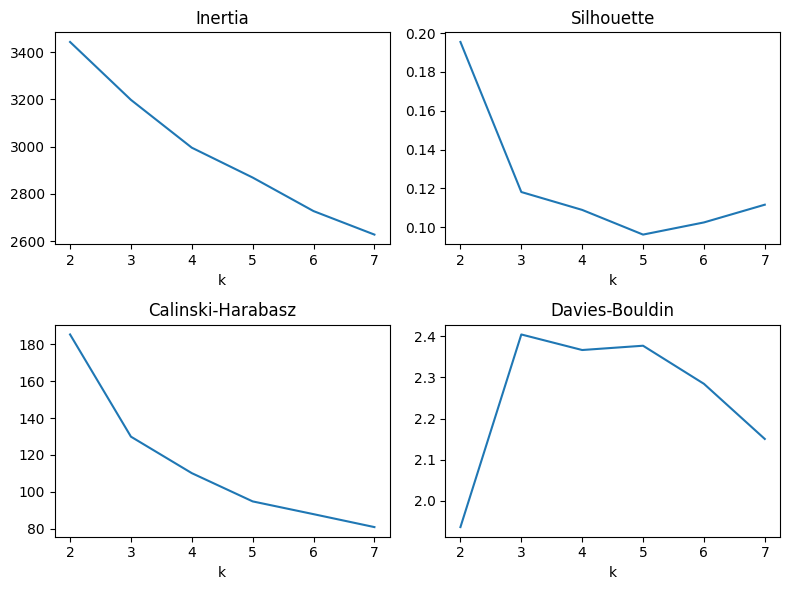

In [133]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

df_metrics["inertia"].plot(ax=axes[0, 0], title="Inertia")

if k_optimal is not None:
    axes[0, 0].axvline(k_optimal, linestyle="--")

df_metrics["silhouette"].plot(ax=axes[0, 1], title="Silhouette")
df_metrics["calinski_harabasz"].plot(ax=axes[1, 0], title="Calinski-Harabasz")
df_metrics["davies_bouldin"].plot(ax=axes[1, 1], title="Davies-Bouldin")

plt.tight_layout()
plt.show()

In [134]:
kmeans_publico = KMeans(n_clusters=2, 
        n_init=10,
        random_state=0
    )
kmeans_publico.fit(X_scaled)
labels = kmeans_publico.labels_

df_clustering['CLUSTER'] = labels


In [135]:
centroids = pd.DataFrame(
    kmeans_publico.cluster_centers_,
    columns=X_scaled.columns
)


centroids[cols_scaler] = scaler.inverse_transform(
    centroids[cols_scaler]
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(centroids.round(2))

,NET_SALES,PROFIT,SHIP_MODE_FIRST CLASS,SHIP_MODE_SAME DAY,SHIP_MODE_SECOND CLASS,SHIP_MODE_STANDARD CLASS,SEGMENT_CONSUMER,SEGMENT_CORPORATE,SEGMENT_HOME OFFICE,REGION_CENTRAL,REGION_EAST,REGION_SOUTH,REGION_WEST,CATEGORY_FURNITURE,CATEGORY_OFFICE SUPPLIES,CATEGORY_TECHNOLOGY,SUB_CATEGORY_ACCESSORIES,SUB_CATEGORY_APPLIANCES,SUB_CATEGORY_ART,SUB_CATEGORY_BINDERS,SUB_CATEGORY_BOOKCASES,SUB_CATEGORY_CHAIRS,SUB_CATEGORY_COPIERS,SUB_CATEGORY_ENVELOPES,SUB_CATEGORY_FASTENERS,SUB_CATEGORY_FURNISHINGS,SUB_CATEGORY_LABELS,SUB_CATEGORY_MACHINES,SUB_CATEGORY_PAPER,SUB_CATEGORY_PHONES,SUB_CATEGORY_STORAGE,SUB_CATEGORY_SUPPLIES,SUB_CATEGORY_TABLES
0,7232.40,245.21,0.17,0.04,0.18,0.6,0.53,0.31,0.16,0.26,0.22,0.22,0.30,0.24,0.57,0.19,0.08,0.04,0.09,0.08,0.04,0.09,0.01,0.03,0.02,0.08,0.03,0.02,0.16,0.08,0.09,0.04,0.03
1,1853.65,51.90,0.14,0.05,0.21,0.6,0.51,0.29,0.20,0.23,0.27,0.16,0.34,0.19,0.67,0.14,0.07,0.05,0.10,0.19,0.01,0.04,0.00,0.03,0.03,0.11,0.05,0.01,0.12,0.07,0.09,0.02,0.02


In [136]:
df_clustering['CLUSTER'].value_counts()

CLUSTER
1    542
0    251
Name: count, dtype: int64